In [1]:
import os
import time
import json
import numpy as np
import matplotlib.pyplot as plt
import tidy3d as td
import tidy3d.web as web
from tidy3d.plugins.resonance import ResonanceFinder

# Import your custom geometry module (Ensure honeycomb_v2.py is in the same directory)
from honeycomb import create_centered_honeycomb_slab

05:09:57 Pacific Standard Time WARNING: Using canonical configuration directory 
                               at 'C:\Users\xtliang\.config\tidy3d'. Found      
                               legacy directory at '~/.tidy3d', which will be   
                               ignored. Remove it manually or run 'tidy3d config
                               migrate --delete-legacy' to clean up.            

In [2]:
web.test()

05:11:01 Pacific Standard Time Authentication configured successfully!

In [2]:
config = {
    "project_name": "Fig2a_Resonance", # Project name for identification
    "note": "switching_absorber",       # Brief note about this specific run
    
    # Geometric Parameters
    "LATTICE_A": 1.0, 
    "DIAMETER": 0.45,
    "h": 0.22,
    "ANGLE": 1.5,
    "GAP": 0.3,
    "num": 44,
    
    # Physical and Material Parameters
    "n_si": 3.47,
    "freq0_THz": 200.0,
    "fwidth_Hz": 1e13,
    
    # Simulation Settings
    "min_steps_per_wvl": 12,
    "run_time_ps": 3.3,  # Simulation time in picoseconds
    "inf_eff": 1e5
}

In [3]:
# Create directories for data and figures if they don't exist
for folder in ["../data", "../figures"]:
    if not os.path.exists(folder):
        os.makedirs(folder)

# Generate a unique filename using a timestamp: YYYYMMDD_HHMMSS
timestamp = time.strftime("%Y%m%d_%H%M%S")
base_filename = f"{timestamp}_{config['project_name']}_{config['note']}"

path_hdf5 = f"../data/{base_filename}.hdf5"
path_json = f"../data/{base_filename}.json"
path_fig  = f"../figures/{base_filename}.png"

print(f"🚀 Task ID: {base_filename}")

🚀 Task ID: 20260119_154704_Fig2a_Resonance_switching_absorber


## Simulation

In [4]:
# Calculate derived physical parameters
ssize = config["num"]
si = td.Medium(permittivity=config["n_si"]**2)
freq0 = config["freq0_THz"] * 1e12
lda0 = td.C_0 / freq0
run_time = config["run_time_ps"] * 1e-12

Lx = config["num"] * config["LATTICE_A"] - lda0
Ly = Lx
Lz = config["h"] * 2 + config["GAP"] + lda0

# --- Building Geometries (Calling custom module) ---
# Bottom slab (0 degree)
structures_0deg = create_centered_honeycomb_slab(
    lattice_const=config["LATTICE_A"],
    disk_diameter=config["DIAMETER"],
    slab_thickness=config["h"],
    twist_angle=0.0,
    domain_size=(ssize, ssize),
    material=si,
    centerz=config["h"]/2,
)

# Top slab (rotated by ANGLE)
structures_twist = create_centered_honeycomb_slab(
    lattice_const=config["LATTICE_A"],
    disk_diameter=config["DIAMETER"],
    slab_thickness=config["h"],
    twist_angle=config["ANGLE"],
    domain_size=(ssize, ssize),
    material=si,
    centerz=config["GAP"] + config["h"] + config["h"]/2,  
)

all_geometry = td.GeometryGroup(geometries=structures_0deg + structures_twist)
structure_new = td.Structure(geometry=all_geometry, medium=si)


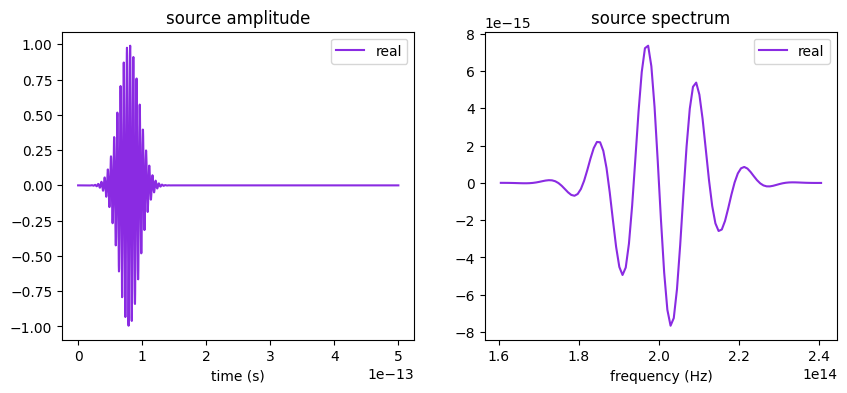

In [5]:
# Dipole source placed between the two slabs
source = td.PointDipole(
    center=(0, 0, (config["h"] * 2 + config["GAP"])/2),
    source_time=td.GaussianPulse(freq0=freq0, fwidth=config["fwidth_Hz"]),
    polarization="Ex",
)

# Source pulse is much shorter than the simulation run_time defined above,
# so we only examine the signal up to a shorter time = 5e-13fs
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
source.source_time.plot(np.linspace(0, 5e-13, 2000), ax=ax[0])
source.source_time.plot_spectrum(times=np.linspace(0, 5e-13, 2000), ax=ax[1])
plt.show()

In [6]:
# Time monitor to record the decaying field for resonance analysis
time_series_mnt = td.FieldTimeMonitor(
    center=[0, 0, (config["h"] * 2 + config["GAP"])/2], 
    size=[0, 0, 0], 
    start=4e-13, # Capture the tail of the simulation
    name="time_series"
)

time_series_mnt2 = td.FieldTimeMonitor(
    center=[0, 0, (config["h"] * 2 + config["GAP"])/2], 
    size=[Lx, Ly, 0], 
    start=0,
    interval = 100,
    interval_space=(3,3,1),
    name="time_series_full"
)
# Initialize the Simulation object
sim = td.Simulation(
    center=(0, 0, (config["h"] * 2 + config["GAP"])/2),
    size=(Lx, Ly, Lz),
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=config["min_steps_per_wvl"], wavelength=lda0),
    structures=[structure_new],
    sources=[source],
    monitors=[time_series_mnt, time_series_mnt2],
    run_time=run_time,
    # boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    boundary_spec=td.BoundarySpec(
        x=td.Boundary.absorber(), y=td.Boundary.absorber(), z=td.Boundary.pml()
    ),
)

print(f"Total number of grid points (millions): {sim.num_cells / 1e6:1.4f}")
print(f"Total number of time steps: {sim.num_time_steps}")

Total number of grid points (millions): 96.9974
Total number of time steps: 48441


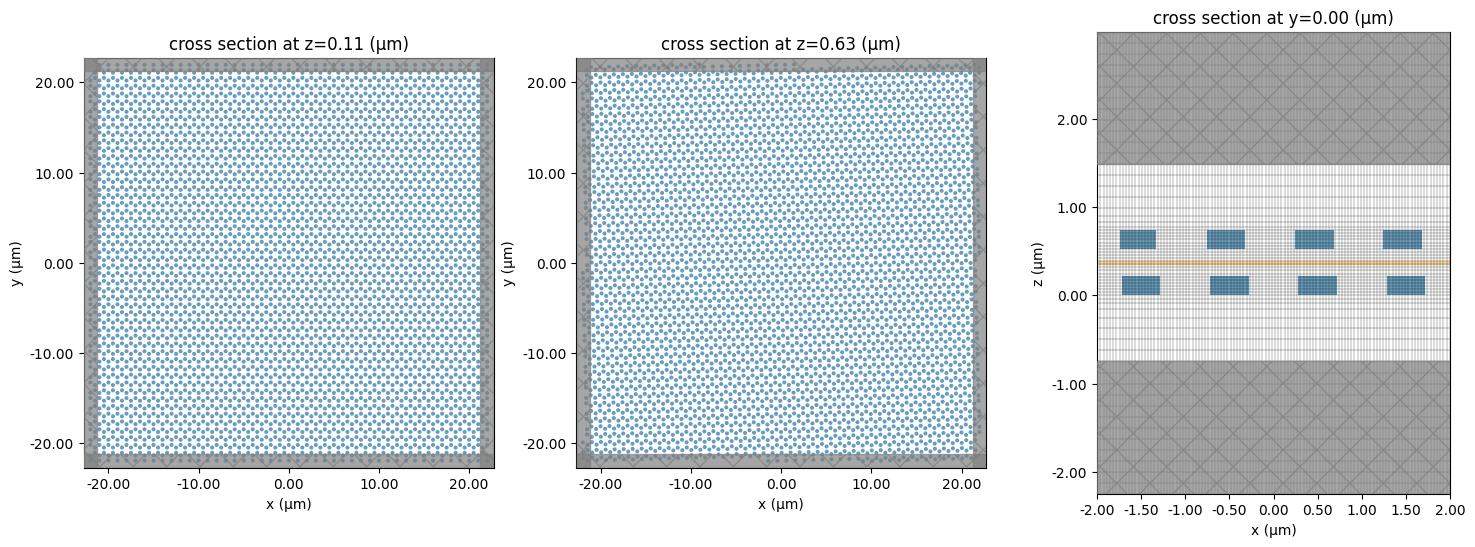

In [87]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,6))

sim.plot(z=config["h"]/2, ax=ax1)
ax1.set_xlim(-Lx/2 - lda0, Lx/2 + lda0)
ax1.set_ylim(-Ly/2 - lda0, Ly/2 + lda0)
sim.plot(z=config["GAP"] + config["h"] + config["h"]/2, ax=ax2)
ax2.set_xlim(-Lx/2 - lda0, Lx/2 + lda0)
ax2.set_ylim(-Ly/2 - lda0, Ly/2 + lda0)

sim.plot(y=1.5, ax=ax3)
sim.plot_grid(y=0, ax=ax3)
ax3.set_xlim(-2, 2)

plt.show()

In [88]:
job = web.Job(simulation=sim, task_name=base_filename)
estimated_cost = web.estimate_cost(job.task_id)

14:53:08 China Standard Time Created task                                       
                             '20260119_145218_Fig2a_Resonance_switching_absorber
                             ' with resource_id                                 
                             'fdve-538956a1-6086-46dd-a967-51152c6ef3e8' and    
                             task_type 'FDTD'.

                             View task using web UI at                          
                             ]8;id=2058;https://tidy3d.simulation.cloud/workbench?taskId=fdve-538956a1-6086-46dd-a967-51152c6ef3e8\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=991707;https://tidy3d.simulation.cloud/workbench?taskId=fdve-538956a1-6086-46dd-a967-51152c6ef3e8\taskId]8;;\]8;id=2058;https://tidy3d.simulation.cloud/workbench?taskId=fdve-538956a1-6086-46dd-a967-51152c6ef3e8\=]8;;\]8;id=616627;https://tidy3d.simulation.cloud/workbench?taskId=fdve-538956a1-6086-46dd-a967-51152c6ef3e8\f]8;;\
                             ]8;id=616627;https://tidy3d.simulation.cloud/workbench?taskId=fdve-538956a1-6086-46dd-a967-51152c6ef3e8\dve]8;;\]8;id=2058;https://tidy3d.simulation.cloud/workbench?taskId=fdve-538956a1-6086-46dd-a967-51152c6ef3e8\-538956a1-6086-46dd-a967-51152c6ef3e8']8;;\.

                             Task folder: ]8;id=254613;https://tidy3d.simulation.cloud/folders/folder-401c0a0c-8e13-4a51-9b19-e6b8ae1b963e\'default']8;;\.

Output()

14:53:13 China Standard Time Estimated FlexCredit cost: 1.441. Minimum cost     
                             depends on task execution details. Use             
                             'web.real_cost(task_id)' to get the billed         
                             FlexCredit cost after a simulation run.

14:53:16 China Standard Time Estimated FlexCredit cost: 1.441. Minimum cost     
                             depends on task execution details. Use             
                             'web.real_cost(task_id)' to get the billed         
                             FlexCredit cost after a simulation run.

14:56:15 China Standard Time status = queued

                             To cancel the simulation, use 'web.abort(task_id)' 
                             or 'web.delete(task_id)' or abort/delete the task  
                             in the web UI. Terminating the Python script will  
                             not stop the job running on the cloud.

Output()

14:56:22 China Standard Time status = preprocess

14:56:27 China Standard Time starting up solver

...

Output()

14:57:46 China Standard Time status = success

14:57:48 China Standard Time View simulation result at                          
                             ]8;id=649350;https://tidy3d.simulation.cloud/workbench?taskId=fdve-538956a1-6086-46dd-a967-51152c6ef3e8\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=562610;https://tidy3d.simulation.cloud/workbench?taskId=fdve-538956a1-6086-46dd-a967-51152c6ef3e8\taskId]8;;\]8;id=649350;https://tidy3d.simulation.cloud/workbench?taskId=fdve-538956a1-6086-46dd-a967-51152c6ef3e8\=]8;;\]8;id=213228;https://tidy3d.simulation.cloud/workbench?taskId=fdve-538956a1-6086-46dd-a967-51152c6ef3e8\f]8;;\
                             ]8;id=213228;https://tidy3d.simulation.cloud/workbench?taskId=fdve-538956a1-6086-46dd-a967-51152c6ef3e8\dve]8;;\]8;id=649350;https://tidy3d.simulation.cloud/workbench?taskId=fdve-538956a1-6086-46dd-a967-51152c6ef3e8\-538956a1-6086-46dd-a967-51152c6ef3e8']8;;\.

Output()

15:00:51 China Standard Time Loading simulation from                            
                             ..\data\20260119_145218_Fig2a_Resonance_switching_a
                             bsorber.hdf5

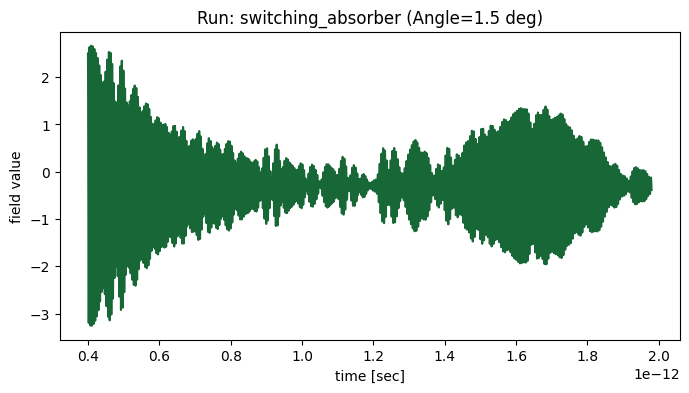

✅ Workflow Completed!
 📊 Data: ../data/20260119_145218_Fig2a_Resonance_switching_absorber.hdf5
 📝 Params: ../data/20260119_145218_Fig2a_Resonance_switching_absorber.json
 🖼️ Figure: ../figures/20260119_145218_Fig2a_Resonance_switching_absorber.png


In [89]:
# A. Save parameters to JSON first (provenance tracking)
with open(path_json, 'w') as f:
    json.dump(config, f, indent=4)

# B. Run simulation via Tidy3D Cloud
# job = web.Job(simulation=sim, task_name=base_filename)
sim_data = job.run(path=path_hdf5)

# C. Post-processing and Visualization
plt.figure(figsize=(8, 4))
# Example: Plotting the time-domain signal
sim_data["time_series"].Ex.plot()
plt.title(f"Run: {config['note']} (Angle={config['ANGLE']} deg)")

# Auto-save the figure for quick reference
plt.savefig(path_fig, dpi=150)
plt.show()

print(f"✅ Workflow Completed!")
print(f" 📊 Data: {path_hdf5}")
print(f" 📝 Params: {path_json}")
print(f" 🖼️ Figure: {path_fig}")

In [11]:
sim_data = td.SimulationData.from_file("../data/20260119_145218_Fig2a_Resonance_switching_absorber.hdf5")

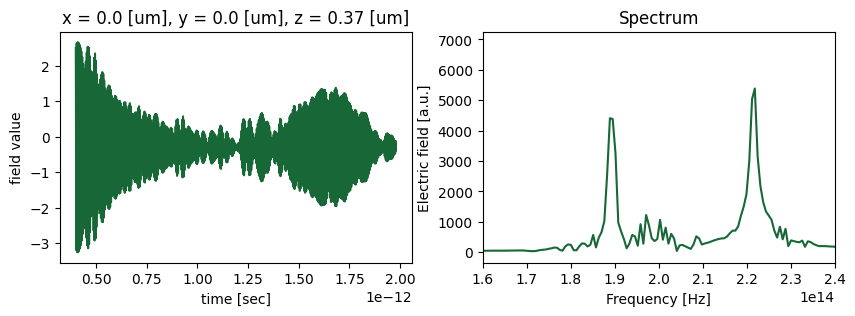

In [12]:
# Get data from the TimeMonitor
tdata = sim_data["time_series"]

time_series = tdata.Ex.squeeze()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# Plot time dependence
time_series.plot(ax=ax1)

# Make frequency mesh and plot spectrum
dt = sim_data.simulation.dt
fmesh = np.linspace(-1 / dt / 2, 1 / dt / 2, time_series.size)
# fmesh = np.linspace(160e12, 240e12, time_series.size)
spectrum = np.fft.fftshift(np.fft.fft(time_series))

ax2.plot(fmesh, np.abs(spectrum))
ax2.set_xlim(1.6e14, 2.4e14)
# ax2.set_xlim(0, 3e14)
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("Electric field [a.u.]")
ax2.set_title("Spectrum")
plt.show()

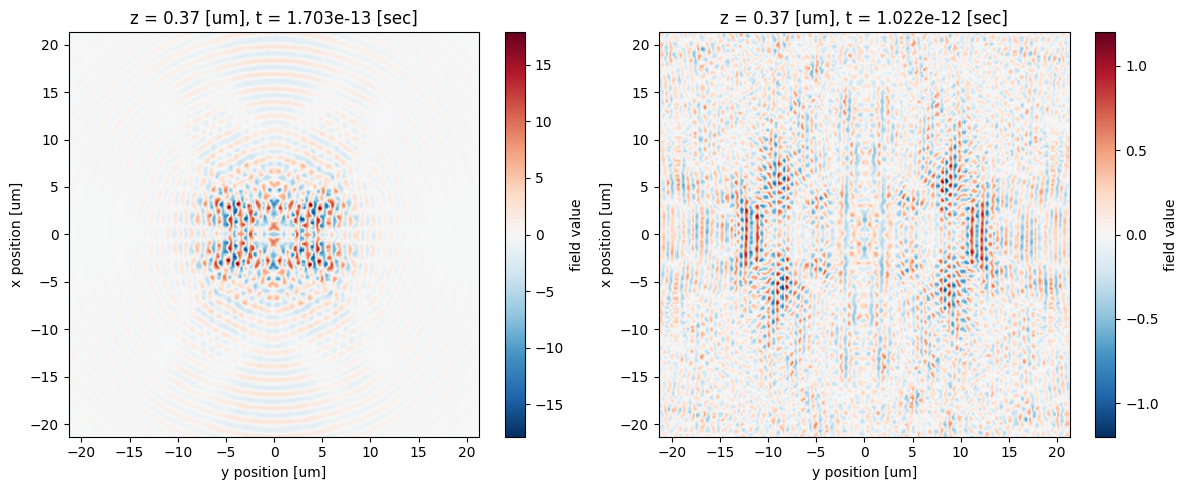

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), tight_layout=True)
# 选择第 1 个时间点（索引为 0）
sim_data["time_series_full"].Ex.isel(t=25).plot(ax=ax[0])

# 选择第 11 个时间点（索引为 10）
sim_data["time_series_full"].Ex.isel(t=150).plot(ax=ax[1])

Phase range: [0.000, 3.142]
Expected range: [-π, π] = [-3.142, 3.142]


Text(0.5, 1.0, 'Phase')

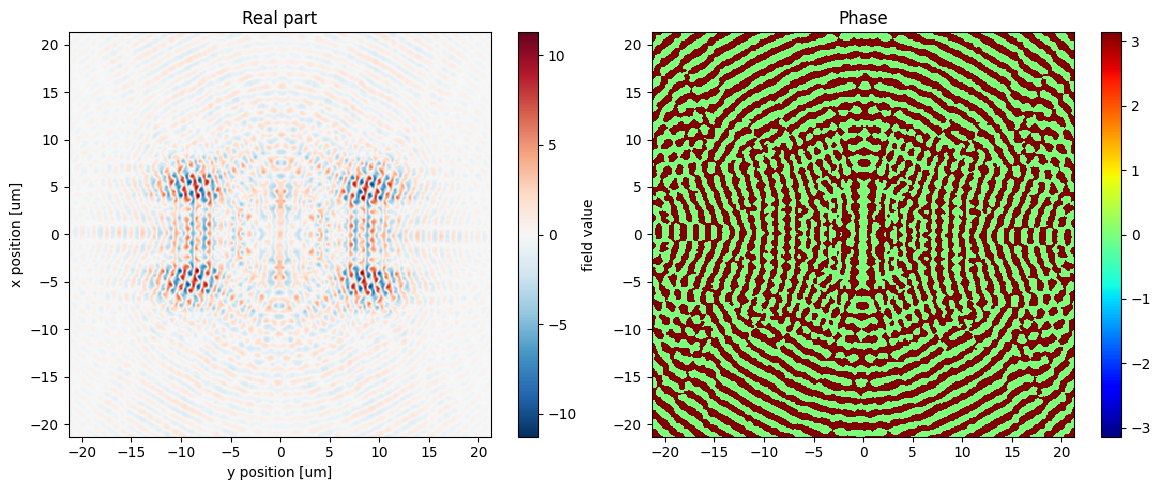

In [25]:
field_data = sim_data["time_series_full"].Ex.isel(t=40).squeeze()
phase = np.angle(field_data)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), tight_layout=True)
field_data.real.plot(ax=ax[0])
ax[0].set_title("Real part")

im = ax[1].pcolormesh(field_data.x, field_data.y, phase, cmap='jet')
plt.colorbar(im, ax=ax[1])
ax[1].set_title("Phase")

Text(0, 0.5, 'y')

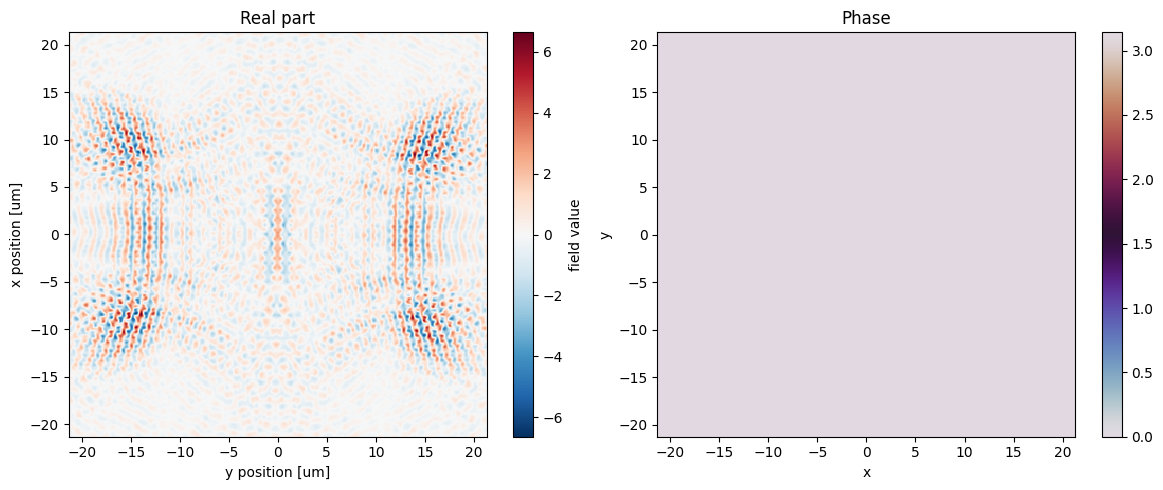

In [21]:
field_data = sim_data["time_series_full"].Ex.isel(t=60).squeeze()
phase = np.angle(field_data)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), tight_layout=True)
field_data.real.plot(ax=ax[0])
ax[0].set_title("Real part")

im = ax[1].imshow(phase.T, extent=[field_data.x.min(), field_data.x.max(), 
                                     field_data.y.min(), field_data.y.max()],
                  origin='lower', cmap='twilight', aspect='auto')
plt.colorbar(im, ax=ax[1])
ax[1].set_title("Phase")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")

In [1]:
from IPython.display import HTML
import matplotlib.animation as animation

t_end = sim_data["time_series_full"].Ex.coords["t"][-1]  # end time of the animation
frames = 50  # number of frames

fig, ax = plt.subplots()


def animate(i):
    t = t_end * i / frames  # time at each frame
    sim_data["time_series_full"].Ex.sel(t=t, method="nearest").plot(
        x="x", y="y", ax=ax, add_colorbar=False,
    )


# create animation
ani = animation.FuncAnimation(fig, animate, frames=frames)
plt.close()

# display the animation
HTML(ani.to_jshtml())

NameError: name 'sim_data' is not defined